In [1]:
#%pip install git+https://github.com/StanfordMIMI/MedVAE.git

## Imports

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from medvae import MVAE

/home/reeves50/.local/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Load Data from preprocess.py

We import the data loaders from our preprocess.py file to ensure consistency.

In [3]:
# Import dataset from preprocess.py
from preprocess import train_dataset, test_dataset

print(f"Data loaded successfully!")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Data loaded successfully!
Training samples: 78468
Test samples: 22433


In [4]:
from torch.utils.data import Subset, DataLoader, Dataset

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False, num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Filtered Training: {len(train_dataset)} single-label images ({len(train_loader)} batches)")
print(f"Filtered Test: {len(test_dataset)} single-label images ({len(test_loader)} batches)")

Filtered Training: 78468 single-label images (2452 batches)
Filtered Test: 22433 single-label images (702 batches)


## Run Autoencoder

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MVAE(
    model_name='medvae_8_1_2d',
    modality='xray',
).to(device)
print(f"Model initialized: {sum(p.numel() for p in model.parameters()):,} parameters\n")
model.eval()

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 1, 64, 64) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Restored from /home/reeves50/.cache/huggingface/hub/models--stanfordmimi--MedVAE/snapshots/8040c5ccb7a51eff6b4cef513c7f20bd1bda983d/model_weights/vae_8x_1c_2D.ckpt with 0 missing and 0 unexpected keys
Model initialized: 83,644,814 parameters



MVAE(
  (model): AutoencoderKL(
    (encoder): Encoder(
      (conv_in): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (down): ModuleList(
        (0): Module(
          (block): ModuleList(
            (0-1): 2 x ResnetBlock(
              (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
              (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            )
          )
          (attn): ModuleList()
          (downsample): Downsample(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
          )
        )
        (1): Module(
          (block): ModuleList(
            (0): ResnetBlock(
              (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
              (conv1): Conv2d(128, 256, ker

In [6]:
@torch.no_grad()
def show_reconstruction(dataloader, num_images=6):
    imgs, labels = next(iter(dataloader))
    imgs = imgs.to(device)

    recon = model(imgs)
    #with torch.no_grad():
    #    recon, _ = model(imgs, decode=True)

    # Ensure same batch size
    imgs = imgs[:num_images]
    recon = recon[:num_images]

    # -----------------------------------------------------
    # Plot original vs reconstruction
    # -----------------------------------------------------
    fig, axes = plt.subplots(2, num_images, figsize=(3*num_images, 6))

    for i in range(num_images):
        # original image
        axes[0, i].imshow(imgs[i, 0].cpu(), cmap='gray')
        axes[0, i].set_title("Original")
        axes[0, i].axis("off")

        # reconstructed image
        # If reconstruction lacks channel dimension, adjust indexing
        if recon.dim() == 4:
            axes[1, i].imshow(recon[i, 0].cpu(), cmap='gray')
        else:
            axes[1, i].imshow(recon[i].cpu(), cmap='gray')

        axes[1, i].set_title("Reconstruction")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


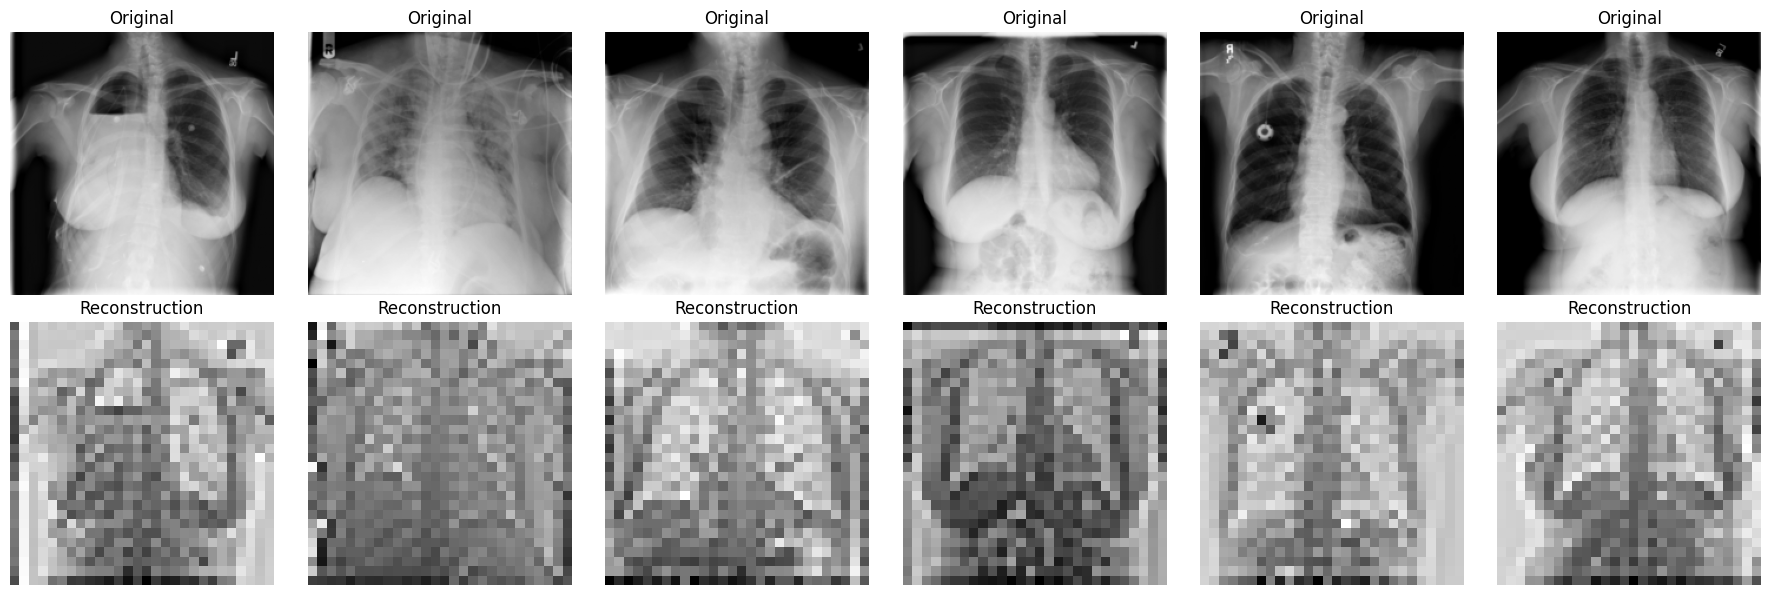

In [7]:
show_reconstruction(train_loader)

In [8]:
@torch.no_grad()
def print_latent_shape(dataloader):
    imgs, labels = next(iter(dataloader))
    imgs = imgs.to(device)

    # Use the encoder module directly
    latent = model.encode(imgs)

    print("\nInput shape: ", imgs.shape)
    print("Latent shape:", latent.shape)

In [9]:
print_latent_shape(train_loader)


Input shape:  torch.Size([32, 1, 224, 224])
Latent shape: torch.Size([32, 1, 28, 28])
